# Case Studies: MAD Estimation on Real Data

This notebook implements the paper's MAD / MAD-Q estimation framework on two real datasets:

1. **Case Study I — Financial Tail Risk (Bitcoin + S&P 500)**  
   Peaks-over-Threshold (Pareto II / Lomax) for VaR & Expected Shortfall, plus monthly Block Maxima (Gumbel / GEV).

2. **Case Study II — Wind Speed & Extreme Gusts**  
   Weibull fit to daily mean wind speed; Gumbel/GEV fit to monthly maximum gusts at Amarillo (gusty plains) and Honolulu (steady coastal).

**Data scripts** (already run): `fetch_bitcoin_data.py`, `fetch_wind_data.py`.  
**Estimators module**: `case_study_estimators.py`.


In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from case_study_estimators import (
    fit_lomax_all, fit_weibull_all, fit_gumbel_all,
    mad_skew_kurt_sample, lmoment_skew_kurt_sample,
    mle_gev, gev_return_level, pot_var_es,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 200, "font.size": 11})
RESULTS = Path("case_study_results.json")
FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)
print("Ready.")


Ready.


## 0. Load datasets

Re-run the fetch scripts if CSVs are missing:
```bash
python fetch_bitcoin_data.py
python fetch_wind_data.py
```


In [5]:
btc_loss = pd.read_csv("bitcoin_daily_losses.csv", parse_dates=["date"])
btc_ret = pd.read_csv("bitcoin_daily_returns.csv", parse_dates=["date"])
print("Bitcoin losses:", len(btc_loss), btc_loss.date.min().date(), "→", btc_loss.date.max().date())
display(btc_loss.head(3))

sites = {
    "gusty_plains": "Amarillo, TX (gusty plains)",
    "steady_coastal": "Honolulu, HI (steady coastal)",
}
wind = {}
for key, label in sites.items():
    hourly = pd.read_csv(f"wind_{key}_hourly_raw.csv", parse_dates=["time"])
    gust = pd.read_csv(f"wind_{key}_monthly_gust_max.csv")
    daily = hourly.set_index("time")["windspeed_10m"].resample("D").mean().dropna()
    wind[key] = dict(label=label, hourly=hourly, daily=daily, gust=gust)
    print(f"{label}: {len(daily)} daily means, mean={daily.mean():.2f} m/s, {len(gust)} monthly gust maxima")


Bitcoin losses: 4359 2014-09-18 → 2026-08-25


,date,loss
0,2014-09-18,0.074643
1,2014-09-19,0.072402
2,2014-09-20,-0.035111


Amarillo, TX (gusty plains): 7670 daily means, mean=4.93 m/s, 252 monthly gust maxima
Honolulu, HI (steady coastal): 7670 daily means, mean=4.59 m/s, 252 monthly gust maxima


## Case Study I — Bitcoin / S&P 500 Tail Risk

### Peaks-over-Threshold (Pareto II / Lomax)

Excesses above the 95% loss quantile are fit with MLE, quartile matching, MAD $L_1$/$L_2$, L-moments, and MAD-Q. VaR and ES at 99% use the GPD formulas with $\xi=1/\alpha$, $\beta=\sigma/\alpha$.


Bitcoin: n=4359, u_95=0.0535, exceedances=218


,Method,alpha,sigma,VaR_99,ES_99,runtime_ms
0,MLE,6.179,0.1647,0.1025,0.1438,9.9
1,Quantile,4.399,0.1270,0.1096,0.1635,0.2
2,L1,3.545,0.0814,0.1003,0.1507,2.0
3,L2,3.545,0.0814,0.1003,0.1507,2.1
4,L-moments,1.841,0.0268,0.0910,0.1675,2.4
5,MAD-Q,3.545,0.0814,0.1003,0.1507,1.7


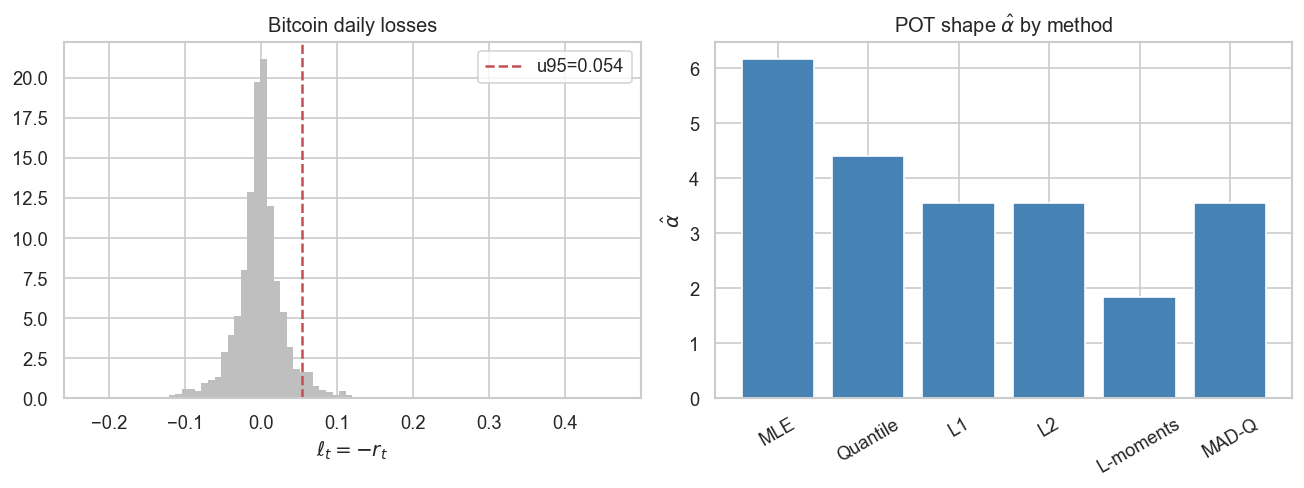

In [6]:
# --- Bitcoin POT ---
ell = btc_loss["loss"].to_numpy(float)
n = len(ell)
u = float(np.quantile(ell, 0.95))
exc = ell[ell > u] - u
print(f"Bitcoin: n={n}, u_95={u:.4f}, exceedances={len(exc)}")

btc_pot = fit_lomax_all(exc, u, n, p_var=0.99)
pot_df = pd.DataFrame([
    dict(Method=r.method, alpha=r.shape, sigma=r.scale,
         VaR_99=r.var99, ES_99=r.es99, runtime_ms=r.runtime_ms)
    for r in btc_pot
])
display(pot_df.style.format({
    "alpha": "{:.3f}", "sigma": "{:.4f}",
    "VaR_99": "{:.4f}", "ES_99": "{:.4f}", "runtime_ms": "{:.1f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(ell, bins=80, color="0.75", edgecolor="none", density=True)
axes[0].axvline(u, color="C3", ls="--", label=f"u95={u:.3f}")
axes[0].set_title("Bitcoin daily losses")
axes[0].set_xlabel(r"$\ell_t = -r_t$"); axes[0].legend()
axes[1].bar(pot_df["Method"], pot_df["alpha"], color="steelblue")
axes[1].set_title(r"POT shape $\hat{\alpha}$ by method")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_ylabel(r"$\hat{\alpha}$")
fig.tight_layout()
fig.savefig(FIGDIR / "case1_bitcoin_pot.png", bbox_inches="tight")
plt.show()


In [7]:
# Optional: S&P 500 companion series
try:
    import yfinance as yf
    sp = yf.download("^GSPC", start="2000-01-01", progress=False)
    close = sp["Close"].squeeze()
    logret = np.log(close / close.shift(1)).dropna()
    ell_sp = (-logret).to_numpy(float)
    n_sp, u_sp = len(ell_sp), float(np.quantile(ell_sp, 0.95))
    exc_sp = ell_sp[ell_sp > u_sp] - u_sp
    spx_pot = fit_lomax_all(exc_sp, u_sp, n_sp, p_var=0.99)
    spx_df = pd.DataFrame([
        dict(Method=r.method, alpha=r.shape, sigma=r.scale,
             VaR_99=r.var99, ES_99=r.es99, runtime_ms=r.runtime_ms)
        for r in spx_pot
    ])
    print(f"S&P 500: n={n_sp}, u95={u_sp:.4f}, exceedances={len(exc_sp)}")
    display(spx_df.style.format({
        "alpha": "{:.3f}", "sigma": "{:.4f}",
        "VaR_99": "{:.4f}", "ES_99": "{:.4f}", "runtime_ms": "{:.1f}",
    }))
except Exception as e:
    spx_pot, spx_df, ell_sp, u_sp = None, None, None, None
    print("S&P 500 download skipped:", e)


S&P 500: n=6699, u95=0.0185, exceedances=335


,Method,alpha,sigma,VaR_99,ES_99,runtime_ms
0,MLE,5.407,0.0488,0.0355,0.0504,6.6
1,Quantile,31.449,0.3062,0.0346,0.0452,0.1
2,L1,1.627,0.0062,0.0290,0.0556,2.8
3,L2,1.627,0.0062,0.0290,0.0556,2.1
4,L-moments,1.821,0.0091,0.0314,0.0583,1.8
5,MAD-Q,1.627,0.0062,0.0290,0.0556,2.1


### Block Maxima (monthly losses → Gumbel / GEV)


Monthly block maxima: 144; GEV-MLE ξ=0.213, μ=0.0524, σ=0.0291
GEV 50-month return level: 0.2294


,Method,loc,scale,z50,runtime_ms
0,MLE,0.0560,0.0326,0.1832,0.6
1,Quantile,0.0536,0.0313,0.1758,0.2
2,L1,0.0523,0.0348,0.1882,0.2
3,L2,0.0523,0.0348,0.1882,0.1
4,L-moments,0.0554,0.0368,0.1990,0.8
5,MAD-Q,0.0523,0.0348,0.1882,0.1


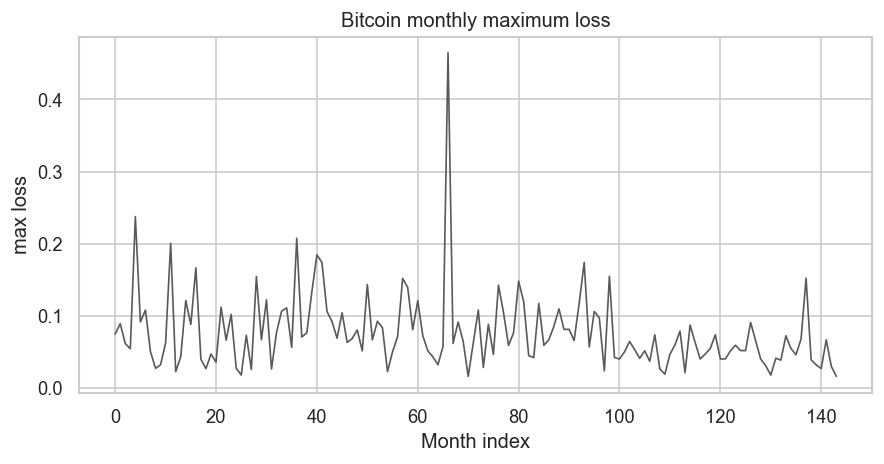

In [8]:
btc_loss = btc_loss.copy()
btc_loss["ym"] = btc_loss["date"].dt.to_period("M")
bm = btc_loss.groupby("ym")["loss"].max().to_numpy(float)
btc_bm = fit_gumbel_all(bm)
xi, mu, sig = mle_gev(bm)
bm_df = pd.DataFrame([
    dict(Method=r.method, loc=r.loc, scale=r.scale, z50=r.extra, runtime_ms=r.runtime_ms)
    for r in btc_bm
])
print(f"Monthly block maxima: {len(bm)}; GEV-MLE ξ={xi:.3f}, μ={mu:.4f}, σ={sig:.4f}")
print(f"GEV 50-month return level: {gev_return_level(mu, sig, xi, 50):.4f}")
display(bm_df.style.format({"loc":"{:.4f}","scale":"{:.4f}","z50":"{:.4f}","runtime_ms":"{:.1f}"}))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(btc_loss.groupby("ym")["loss"].max().values, color="0.35", lw=1)
ax.set_title("Bitcoin monthly maximum loss")
ax.set_xlabel("Month index"); ax.set_ylabel("max loss")
fig.tight_layout(); fig.savefig(FIGDIR / "case1_bitcoin_blockmax.png", bbox_inches="tight"); plt.show()


In [9]:
# MAD vs L-moment skewness / kurtosis on POT exceedances and block maxima
rows = []
for name, sample, alpha_or_xi in [
    ("Bitcoin POT excesses", exc, next(r.shape for r in btc_pot if r.method=="MAD-Q")),
    ("Bitcoin monthly maxima", bm, xi),
]:
    G, K = mad_skew_kurt_sample(sample)
    t3, t4 = lmoment_skew_kurt_sample(sample)
    rows.append(dict(Series=name, shape=alpha_or_xi, MAD_G=G, MAD_K=K, Lmom_t3=t3, Lmom_t4=t4,
                     classical_skew=float(pd.Series(sample).skew()),
                     classical_kurt=float(pd.Series(sample).kurtosis())))
skew_df = pd.DataFrame(rows)
display(skew_df.style.format("{:.3f}", subset=[c for c in skew_df.columns if c!="Series"]))


,Series,shape,MAD_G,MAD_K,Lmom_t3,Lmom_t4,classical_skew,classical_kurt
0,Bitcoin POT excesses,3.545,0.587,1.300,0.426,0.236,4.532,34.644
1,Bitcoin monthly maxima,0.213,0.338,1.335,0.298,0.218,3.182,18.319


## Case Study II — Wind Speed (Weibull) & Gusts (Gumbel/GEV)

Amarillo (gusty plains) vs Honolulu (steady coastal), ERA5 via Open-Meteo.



=== Amarillo, TX (gusty plains) — Weibull (daily mean wind) ===


,Method,k,c,mean_speed,runtime_ms
0,MLE,3.128,5.512,4.932,20.6
1,Quantile,3.152,5.421,4.852,0.4
2,L1,2.377,4.242,3.760,3.4
3,L2,2.377,4.242,3.760,2.7
4,L-moments,3.231,5.502,4.930,41.5
5,MAD-Q,2.377,4.242,3.760,2.7



=== Honolulu, HI (steady coastal) — Weibull (daily mean wind) ===


,Method,k,c,mean_speed,runtime_ms
0,MLE,2.935,5.148,4.593,16.0
1,Quantile,2.616,5.190,4.611,0.4
2,L1,2.616,4.960,4.406,1.7
3,L2,2.616,4.960,4.406,1.5
4,L-moments,2.834,5.148,4.586,41.8
5,MAD-Q,2.616,4.960,4.406,1.7


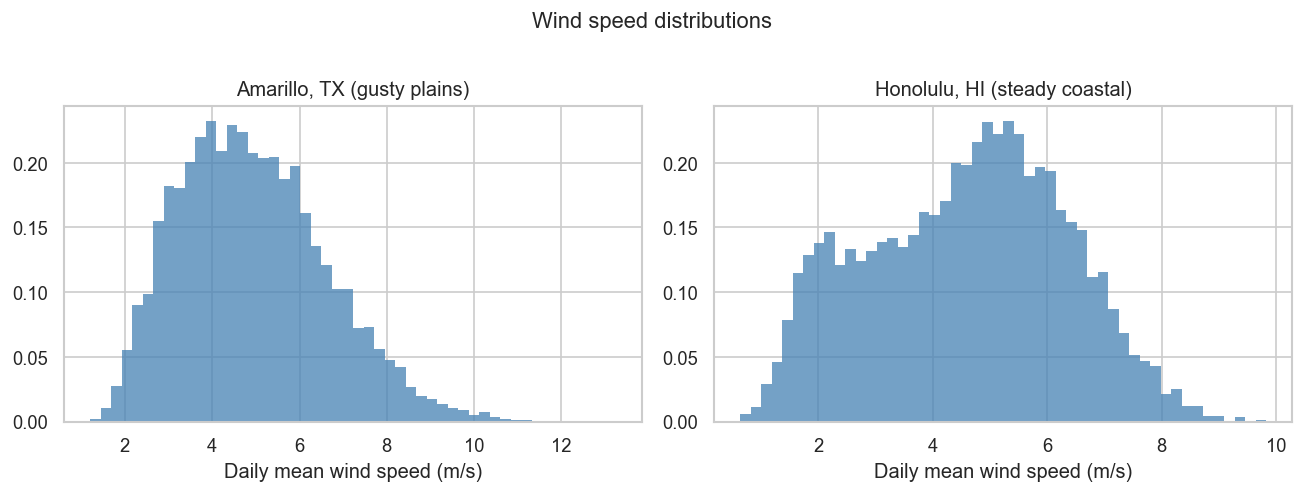

In [10]:
wind_tables = {}
for key, pack in wind.items():
    daily = pack["daily"].to_numpy(float)
    wfit = fit_weibull_all(daily)
    wdf = pd.DataFrame([
        dict(Method=r.method, k=r.shape, c=r.scale, mean_speed=r.extra, runtime_ms=r.runtime_ms)
        for r in wfit
    ])
    wind_tables[key] = wdf
    print("\n===", pack["label"], "— Weibull (daily mean wind) ===")
    display(wdf.style.format({"k":"{:.3f}","c":"{:.3f}","mean_speed":"{:.3f}","runtime_ms":"{:.1f}"}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (key, pack) in zip(axes, wind.items()):
    ax.hist(pack["daily"], bins=50, density=True, color="steelblue", alpha=0.75, edgecolor="none")
    ax.set_title(pack["label"])
    ax.set_xlabel("Daily mean wind speed (m/s)")
fig.suptitle("Wind speed distributions", y=1.02)
fig.tight_layout(); fig.savefig(FIGDIR / "case2_wind_speed_hist.png", bbox_inches="tight"); plt.show()



=== Amarillo, TX (gusty plains) — monthly max gust (Gumbel / GEV) ===
GEV-MLE ξ=-0.107, 50-month return level=27.99 m/s


,Method,loc,scale,z50,runtime_ms
0,MLE,18.35,2.88,29.58,0.6
1,Quantile,18.53,3.07,30.50,0.4
2,L1,18.61,2.83,29.66,0.5
3,L2,18.61,2.83,29.66,0.7
4,L-moments,18.37,2.74,29.08,1.5
5,MAD-Q,18.61,2.83,29.66,0.3



=== Honolulu, HI (steady coastal) — monthly max gust (Gumbel / GEV) ===
GEV-MLE ξ=-0.108, 50-month return level=23.66 m/s


,Method,loc,scale,z50,runtime_ms
0,MLE,17.06,2.03,24.99,0.6
1,Quantile,17.39,1.67,23.90,0.3
2,L1,17.37,1.71,24.05,0.5
3,L2,17.37,1.71,24.05,0.4
4,L-moments,17.11,1.75,23.93,1.5
5,MAD-Q,17.37,1.71,24.05,0.1


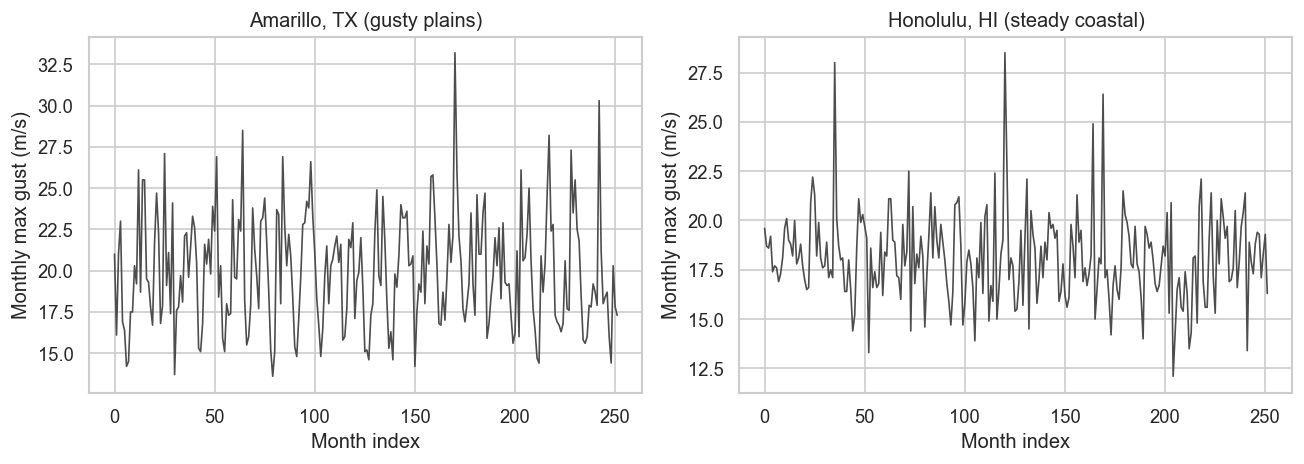

In [11]:
gust_tables = {}
for key, pack in wind.items():
    gm = pack["gust"]["monthly_max_gust_ms"].to_numpy(float)
    gfit = fit_gumbel_all(gm)
    xi_g, mu_g, sig_g = mle_gev(gm)
    gdf = pd.DataFrame([
        dict(Method=r.method, loc=r.loc, scale=r.scale, z50=r.extra, runtime_ms=r.runtime_ms)
        for r in gfit
    ])
    gust_tables[key] = (gdf, xi_g, mu_g, sig_g)
    print("\n===", pack["label"], "— monthly max gust (Gumbel / GEV) ===")
    print(f"GEV-MLE ξ={xi_g:.3f}, 50-month return level={gev_return_level(mu_g,sig_g,xi_g,50):.2f} m/s")
    display(gdf.style.format({"loc":"{:.2f}","scale":"{:.2f}","z50":"{:.2f}","runtime_ms":"{:.1f}"}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (key, pack) in zip(axes, wind.items()):
    ax.plot(pack["gust"]["monthly_max_gust_ms"].values, color="0.3", lw=1)
    ax.set_title(pack["label"])
    ax.set_ylabel("Monthly max gust (m/s)")
    ax.set_xlabel("Month index")
fig.tight_layout(); fig.savefig(FIGDIR / "case2_wind_gusts.png", bbox_inches="tight"); plt.show()


In [12]:
# Skewness / kurtosis comparison for wind fits
wrows = []
for key, pack in wind.items():
    daily = pack["daily"].to_numpy(float)
    gm = pack["gust"]["monthly_max_gust_ms"].to_numpy(float)
    k_hat = float(wind_tables[key].loc[wind_tables[key].Method=="MAD-Q", "k"].iloc[0])
    xi_g = gust_tables[key][1]
    for series, sample, shape in [
        (f"{pack['label']} wind (Weibull)", daily, k_hat),
        (f"{pack['label']} gust max (GEV)", gm, xi_g),
    ]:
        G, K = mad_skew_kurt_sample(sample)
        t3, t4 = lmoment_skew_kurt_sample(sample)
        wrows.append(dict(
            Series=series, shape=shape, MAD_G=G, MAD_K=K, Lmom_t3=t3, Lmom_t4=t4,
            classical_skew=float(pd.Series(sample).skew()),
            classical_kurt=float(pd.Series(sample).kurtosis()),
        ))
wind_skew = pd.DataFrame(wrows)
display(wind_skew.style.format("{:.3f}", subset=[c for c in wind_skew.columns if c!="Series"]))


,Series,shape,MAD_G,MAD_K,Lmom_t3,Lmom_t4,classical_skew,classical_kurt
0,"Amarillo, TX (gusty plains) wind (Weibull)",2.377,0.117,1.140,0.093,0.099,0.516,0.034
1,"Amarillo, TX (gusty plains) gust max (GEV)",-0.107,0.112,1.090,0.082,0.094,0.532,0.309
2,"Honolulu, HI (steady coastal) wind (Weibull)",2.616,-0.100,1.130,-0.024,0.066,-0.052,-0.746
3,"Honolulu, HI (steady coastal) gust max (GEV)",-0.108,0.071,1.249,0.069,0.178,0.867,3.119


## Persist results

Writes `case_study_results.json` for the paper tables in `main_mdpi.tex`.


Loaded case_study_results.json keys: ['meta', 'bitcoin_pot', 'bitcoin_bm_gumbel', 'bitcoin_bm_gev_mle', 'bitcoin_skewkurt_pot', 'bitcoin_skewkurt_bm', 'spx_pot', 'spx_skewkurt_pot'] ...


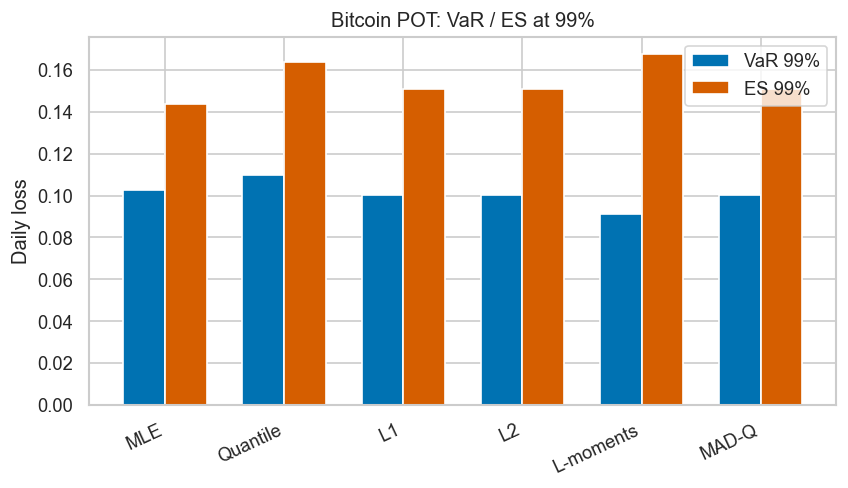

Figures written under figures/


In [13]:
# Reload canonical JSON if present, else build from this session
if RESULTS.exists():
    data = json.loads(RESULTS.read_text())
    print("Loaded", RESULTS, "keys:", list(data)[:8], "...")
else:
    print("Run the top-level results script or re-execute fits to populate JSON.")

# Side-by-side VaR/ES comparison figure for Bitcoin
fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.arange(len(pot_df))
w = 0.35
ax.bar(x - w/2, pot_df["VaR_99"], width=w, label="VaR 99%", color="#0072B2")
ax.bar(x + w/2, pot_df["ES_99"], width=w, label="ES 99%", color="#D55E00")
ax.set_xticks(x, pot_df["Method"], rotation=25, ha="right")
ax.set_ylabel("Daily loss")
ax.set_title("Bitcoin POT: VaR / ES at 99%")
ax.legend()
fig.tight_layout(); fig.savefig(FIGDIR / "case1_bitcoin_var_es.png", bbox_inches="tight"); plt.show()
print("Figures written under figures/")
